In [1]:
import torch
torch.__version__

'2.6.0+cu126'

In [4]:
import pandas as od
import numpy as np
import matplotlib.pyplot as plt
from torch import nn

In [12]:
#Data Creation/ Loading
weight=0.7
bias=0.3
X=torch.arange(0,1,0.02).unsqueeze(dim=1)
y=bias + weight * X
print(len(X), len(y))
X[:7] , y[:7]

50 50


(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840]]))

In [13]:
split=int(0.8*len(X))
x_train,y_train = X[:split],y[:split]
x_test,y_test = X[split:],y[split:]
x_test

tensor([[0.8000],
        [0.8200],
        [0.8400],
        [0.8600],
        [0.8800],
        [0.9000],
        [0.9200],
        [0.9400],
        [0.9600],
        [0.9800]])

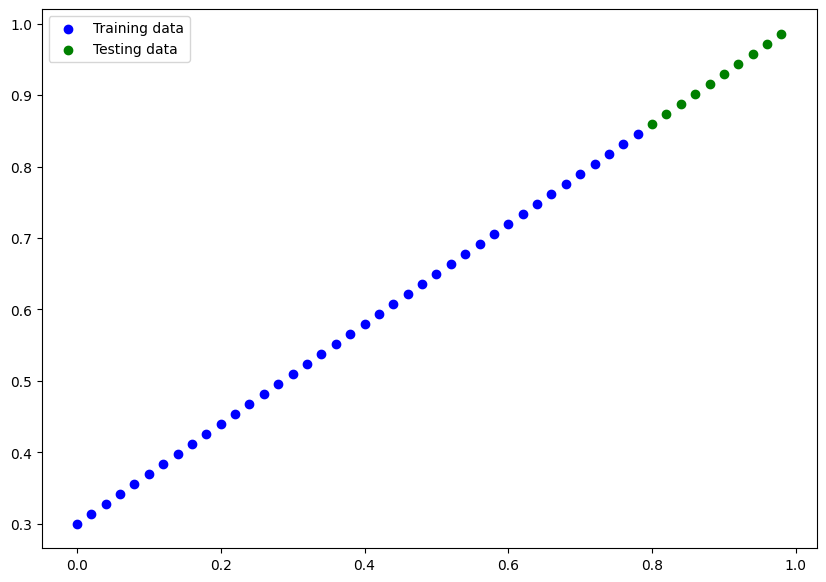

In [19]:
def plot_predictions(train_data=x_train,train_labels=y_train,test_data=x_test,test_labels=y_test,predictions=None):
    plt.figure(figsize=(10,7))
    plt.scatter(train_data,train_labels,c="b",label="Training data")
    plt.scatter(test_data,test_labels,c="g",label="Testing data")
    if predictions:
        plt.scatter(test_data,predictions,c="r",label="Predictions")
    plt.legend(prop={"size":10})
plot_predictions()

In [ ]:
#model
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1,requires_grad=True,dtype=torch.float))
        self.biase = nn.Parameter(torch.rand(1,requires_grad=True,dtype=torch.float))
    def forward(self x:torch.Tensor) -> torch.Tensor:
        return self.weights * x + self.bias